# 실습 1. 결정트리 사전 가지치기

## 데이터
- 데이터셋: `sklearn.datasets.load_breast_cancer()`
- 데이터 내용: 유방암 진단에 사용되는 종양의 반지름, 질감, 면적, 오목도 등 수치 feature
- target: 종양 진단 결과
  - `0`: malignant, 악성
  - `1`: benign, 양성

## 실습 목표
- 결정트리 분류 모델의 기본 학습 흐름을 복습
- 사전 가지치기 하이퍼파라미터 3가지를 비교
  - `max_depth`
  - `min_samples_split`
  - `min_samples_leaf`
- 각 설정에 따라 `score()` 결과가 어떻게 변하는지 확인
- `GridSearchCV`로 여러 가지치기 후보를 한 번에 비교
- `feature_importances_`로 결정트리가 중요하게 사용한 feature 확인
- 학습셋 점수와 평가셋 점수를 함께 보며 과대적합과 과소적합을 해석

## 참고
- 결정트리는 feature 스케일링이 필수는 아님.
- 이번 실습은 성능을 최고로 만드는 것이 아니라, 가지치기 설정을 바꾸면 모델 복잡도와 점수가 달라진다는 점을 확인하는 것이 목적임.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

# load_breast_cancer(as_frame=True): 유방암 분류 예제 데이터를 DataFrame 형태로 불러옴.
cancer = load_breast_cancer(as_frame=True)

cancer_df = cancer.frame.copy()
X = cancer.data
y = cancer.target

print('데이터 크기:', cancer_df.shape)
print('feature 개수:', X.shape[1])
print('target 이름:', cancer.target_names)
print()
print('target 분포')
print(y.value_counts().sort_index())

display(cancer_df.head())



데이터 크기: (569, 31)
feature 개수: 30
target 이름: ['malignant' 'benign']

target 분포
target
0    212
1    357
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## 문제 1. 학습/평가 데이터 분리

`train_test_split()`으로 학습 데이터와 평가 데이터를 분리하세요.

### 요구사항
- `test_size=0.25` 사용
- `random_state=42` 사용
- `stratify=y` 사용
- 분리 결과의 shape 출력

### 힌트
- 분류 문제에서 클래스 비율을 유지하려면 `stratify=y`를 사용함.

### 실행 결과
```text
X_train: (426, 30)
X_test: (143, 30)
y_train: (426,)
y_test: (143,)
```



In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (426, 30)
X_test: (143, 30)
y_train: (426,)
y_test: (143,)


## 문제 2. 기본 결정트리 모델 학습

가지치기 옵션을 주지 않은 기본 결정트리 모델을 학습하고 점수를 확인하세요.

### 요구사항
- 모델 변수명은 `base_tree` 사용
- `DecisionTreeClassifier(random_state=42)` 사용
- 학습셋 score와 평가셋 score 출력
- 트리 깊이와 leaf node 개수 출력
- `classification_report()` 출력

### 해석 포인트
- 학습셋 score가 매우 높고 평가셋 score가 상대적으로 낮으면 과대적합 가능성이 있음.

### 실행 결과
```text
학습셋 score: 1.0
평가셋 score: 0.9230769230769231
트리 깊이: 7
leaf node 개수: 18

              precision    recall  f1-score   support

   malignant       0.88      0.92      0.90        53
      benign       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143
```



In [11]:
from sklearn.metrics import classification_report

base_tree = DecisionTreeClassifier(random_state=42)

base_tree.fit(X_train, y_train)

print('학습셋:', base_tree.score(X_train, y_train))
print('평가셋:', base_tree.score(X_test, y_test))
print('트리 깊이:', base_tree.get_depth())
print('leaf node 개수:', base_tree.get_n_leaves())

print(classification_report(y_test, base_tree.predict(X_test)))


학습셋: 1.0
평가셋: 0.9230769230769231
트리 깊이: 7
leaf node 개수: 18
              precision    recall  f1-score   support

           0       0.88      0.92      0.90        53
           1       0.95      0.92      0.94        90

    accuracy                           0.92       143
   macro avg       0.91      0.92      0.92       143
weighted avg       0.92      0.92      0.92       143



## 문제 3. `max_depth` 변화에 따른 score 비교

`max_depth`는 트리의 최대 깊이를 제한하는 사전 가지치기 방법입니다.

### 요구사항
- 후보값: `[None, 2, 3, 4, 5, 7]`
- 각 후보마다 모델 학습
- 학습셋 score, 평가셋 score, 트리 깊이, leaf node 개수를 표로 정리

### 해석 포인트
- `max_depth`가 작으면 트리가 단순해져 과소적합될 수 있음.
- `max_depth`가 너무 크면 훈련 데이터를 세밀하게 외워 과대적합될 수 있음.

### 실행 결과
| max_depth | train_score | test_score | tree_depth | leaf_count |
|---|---:|---:|---:|---:|
| None | 1.000000 | 0.923077 | 7 | 18 |
| 2 | 0.957746 | 0.909091 | 2 | 4 |
| 3 | 0.976526 | 0.944056 | 3 | 7 |
| 4 | 0.988263 | 0.944056 | 4 | 11 |
| 5 | 0.995305 | 0.937063 | 5 | 15 |
| 7 | 1.000000 | 0.923077 | 7 | 18 |



In [15]:
max_depth_options = [None, 2, 3, 4, 5, 7]
depth_result = []

for max_depth in max_depth_options:
    models = DecisionTreeClassifier(
        random_state=42,
        max_depth=max_depth
    )

    models.fit(X_train, y_train)


    depth_result.append({
        'max_depth': 'None' if max_depth is None else max_depth,
        'train_score': models.score(X_train, y_train),
        'test_score': models.score(X_test, y_test),
        'tree_depth': models.get_depth(),
        'leaf_count': models.get_n_leaves()
     })

depth_result_df = pd.DataFrame(depth_result).round(4)
display(depth_result_df)

,max_depth,train_score,test_score,tree_depth,leaf_count
0,None,1.0000,0.9231,7,18
1,2,0.9577,0.9091,2,4
2,3,0.9765,0.9441,3,7
3,4,0.9883,0.9441,4,11
4,5,0.9953,0.9371,5,15
5,7,1.0000,0.9231,7,18


## 문제 4. `min_samples_split` 변화에 따른 score 비교

`min_samples_split`은 노드를 추가로 나누기 위해 필요한 최소 샘플 수를 제한합니다.

### 요구사항
- 후보값: `[2, 5, 10, 20, 50]`
- 각 후보마다 모델 학습
- 학습셋 score, 평가셋 score, 트리 깊이, leaf node 개수를 표로 정리

### 해석 포인트
- 값이 커질수록 작은 노드는 더 이상 나누기 어려워져 트리가 단순해질 수 있음.

### 실행 결과
| min_samples_split | train_score | test_score | tree_depth | leaf_count |
|---:|---:|---:|---:|---:|
| 2 | 1.000000 | 0.923077 | 7 | 18 |
| 5 | 0.992958 | 0.930070 | 7 | 15 |
| 10 | 0.988263 | 0.923077 | 7 | 14 |
| 20 | 0.978873 | 0.944056 | 6 | 11 |
| 50 | 0.962441 | 0.909091 | 6 | 9 |



In [18]:
min_sample_split_options = [2, 5, 10, 20, 50]
split_result = []

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

for min_sample in min_sample_split_options:
    model = DecisionTreeClassifier(
        random_state=42,
        min_samples_split=min_sample
    )

    model.fit(X_train, y_train)

    split_result.append({
        'min_samples_split': min_sample,
        'train_score': model.score(X_train, y_train),
        'test_score': model.score(X_test, y_test),
        'tree_depth': model.get_depth(),
        'leaf_count': model.get_n_leaves()
    })

split_result_df = pd.DataFrame(split_result).round(4)
display(split_result_df)

,min_samples_split,train_score,test_score,tree_depth,leaf_count
0,2,1.0000,0.9231,7,18
1,5,0.9930,0.9301,7,15
2,10,0.9883,0.9231,7,14
3,20,0.9789,0.9441,6,11
4,50,0.9624,0.9091,6,9


## 문제 5. `min_samples_leaf` 변화에 따른 score 비교

`min_samples_leaf`는 leaf node에 남아 있어야 하는 최소 샘플 수를 제한합니다.

### 요구사항
- 후보값: `[1, 2, 5, 10, 20]`
- 각 후보마다 모델 학습
- 학습셋 score, 평가셋 score, 트리 깊이, leaf node 개수를 표로 정리

### 해석 포인트
- leaf에 너무 적은 샘플만 남는 것을 막으면 예외 샘플을 외우는 현상을 줄일 수 있음.

### 실행 결과
| min_samples_leaf | train_score | test_score | tree_depth | leaf_count |
|---:|---:|---:|---:|---:|
| 1 | 1.000000 | 0.923077 | 7 | 18 |
| 2 | 0.990610 | 0.895105 | 6 | 16 |
| 5 | 0.976526 | 0.930070 | 6 | 12 |
| 10 | 0.962441 | 0.951049 | 5 | 10 |
| 20 | 0.946009 | 0.916084 | 4 | 8 |



In [24]:
min_samples_leaf_options = [2, 5, 10, 20, 50]
leaf_result = []

for min_samples_leaf in min_samples_leaf_options:
    model = DecisionTreeClassifier(
        random_state=42,
        min_samples_leaf=min_samples_leaf
    )

    model.fit(X_train, y_train)

    leaf_result.append({
        'min_samples_leaf': min_samples_leaf,
        'train_score': model.score(X_train, y_train),
        'test_score': model.score(X_test, y_test),
        'tree_depth': model.get_depth(),
        'leaf_count': model.get_n_leaves()
    })

leaf_result_df = pd.DataFrame(leaf_result).round(4)
display(leaf_result_df)

,min_samples_leaf,train_score,test_score,tree_depth,leaf_count
0,2,0.9906,0.8951,6,16
1,5,0.9765,0.9301,6,12
2,10,0.9624,0.9510,5,10
3,20,0.9460,0.9161,4,8
4,50,0.9225,0.9231,3,5


## 문제 6. 세 가지 사전 가지치기 결과 시각화

세 가지 가지치기 방법의 평가셋 score 변화를 그래프로 비교하세요.

### 요구사항
- `max_depth_df`, `split_df`, `leaf_df`를 사용
- x축은 후보값, y축은 `test_score`
- 세 개의 그래프를 한 화면에 표시

### 해석 포인트
- 가장 높은 평가셋 score만 볼 것이 아니라, 학습셋과 평가셋 차이, 트리 깊이, leaf 개수도 함께 봐야 함.

### 실행 결과
- 한 화면에 3개의 선 그래프가 출력됨.
- `max_depth` 그래프는 `3`, `4`에서 test score가 높게 보임.
- `min_samples_split` 그래프는 `20`에서 test score가 높게 보임.
- `min_samples_leaf` 그래프는 `10`에서 test score가 가장 높게 보임.



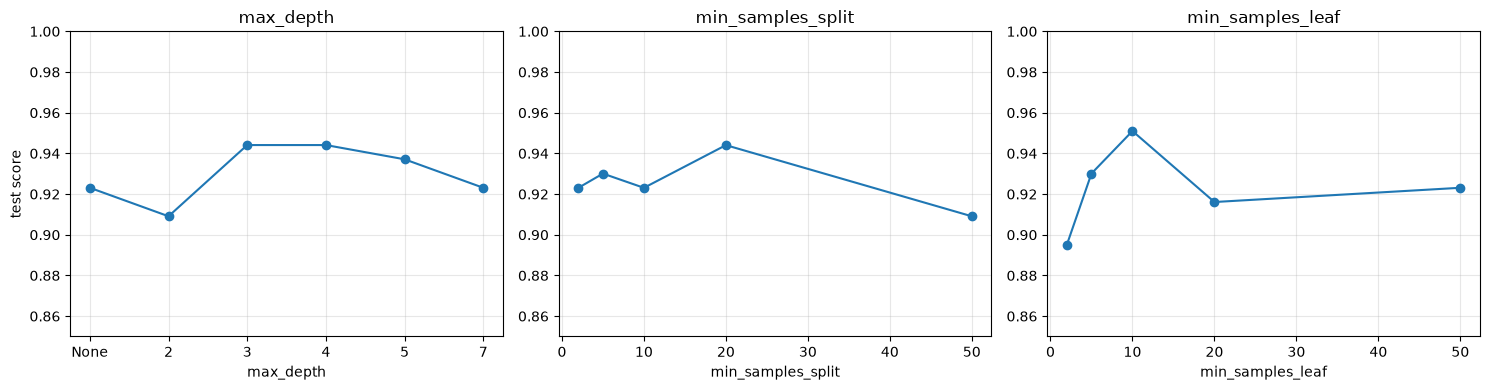

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(depth_result_df['max_depth'].astype(str), depth_result_df['test_score'], marker='o')
axes[0].set_title('max_depth')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('test score')
axes[0].set_ylim(0.85, 1.0)
axes[0].grid(alpha=0.3)

axes[1].plot(split_result_df['min_samples_split'], split_result_df['test_score'], marker='o')
axes[1].set_title('min_samples_split')
axes[1].set_xlabel('min_samples_split')
axes[1].set_ylim(0.85, 1.0)
axes[1].grid(alpha=0.3)

axes[2].plot(leaf_result_df['min_samples_leaf'], leaf_result_df['test_score'], marker='o')
axes[2].set_title('min_samples_leaf')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylim(0.85, 1.0)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 알 수 있는 점: 사전 가지치기 값이 바뀌면 모델 복잡도와 평가셋 score가 함께 변함.



## 문제 7. 결과 정리

세 가지 방법 중 평가셋 score가 가장 좋은 후보를 찾아보세요.

### 요구사항
- 각 DataFrame에서 `test_score`가 가장 높은 행을 찾기
- 세 결과를 하나의 표로 정리
- 단순히 score만 보지 말고 `tree_depth`, `leaf_count`도 함께 비교

### 실행 결과
| method | max_depth | min_samples_split | min_samples_leaf | train_score | test_score | tree_depth | leaf_count |
|---|---:|---:|---:|---:|---:|---:|---:|
| max_depth | 3 |  |  | 0.976526 | 0.944056 | 3 | 7 |
| min_samples_split |  | 20 |  | 0.978873 | 0.944056 | 6 | 11 |
| min_samples_leaf |  |  | 10 | 0.962441 | 0.951049 | 5 | 10 |



In [26]:
best_depth = depth_result_df.loc[depth_result_df['test_score'].idxmax()].copy()
best_split = split_result_df.loc[split_result_df['test_score'].idxmax()].copy()
best_leaf = leaf_result_df.loc[leaf_result_df['test_score'].idxmax()].copy()

best_depth['method'] = 'max_depth'
best_split['method'] = 'min_samples_split'
best_leaf['method'] = 'min_samples_leaf'

best_result_df = pd.DataFrame([best_depth, best_split, best_leaf])

best_result_df = best_result_df[
    [
        'method',
        'max_depth',
        'min_samples_split',
        'min_samples_leaf',
        'train_score',
        'test_score',
        'tree_depth',
        'leaf_count'
    ]
]

display(best_result_df)

,method,max_depth,min_samples_split,min_samples_leaf,train_score,test_score,tree_depth,leaf_count
2,max_depth,3.0,NaN,NaN,0.976500,0.944100,3.0,7.0
3,min_samples_split,NaN,20.0,NaN,0.978873,0.944056,6.0,11.0
2,min_samples_leaf,NaN,NaN,10.0,0.962400,0.951000,5.0,10.0


## 문제 8. `GridSearchCV`로 가지치기 후보 한 번에 비교

앞에서는 `max_depth`, `min_samples_split`, `min_samples_leaf`를 각각 따로 비교했습니다. 이번에는 `GridSearchCV`로 세 가지 사전 가지치기 후보 조합을 한 번에 비교하세요.

### 요구사항
- 기준 모델: `DecisionTreeClassifier(random_state=42)`
- 후보값
  - `max_depth`: `[2, 3, 4, 5, None]`
  - `min_samples_split`: `[2, 10, 20]`
  - `min_samples_leaf`: `[1, 5, 10]`
- `cv=5` 사용
- `scoring='accuracy'` 사용
- `n_jobs=1` 사용
- `best_params_`, `best_score_` 출력
- 최종 선택 모델의 학습셋 score, 평가셋 score, 트리 깊이, leaf node 개수 출력

### 힌트
- `best_score_`는 교차검증 평균 점수임.
- `best_score_`와 평가셋 score는 같은 값이 아님.
- 교차검증으로 고른 모델도 마지막에는 따로 둔 평가셋에서 다시 확인해야 함.

### 실행 결과
```text
best_params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
best_cv_score: 0.934391244870041
학습셋 score: 0.9882629107981221
평가셋 score: 0.9230769230769231
트리 깊이: 7
leaf node 개수: 14
```



In [30]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

base_model = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_model,
    param_grid=param_grid,
    cv=5,
    n_jobs=1,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print('best_params:', grid_search.best_params_)
print('best_score:', grid_search.best_score_)

iris_best_model = grid_search.best_estimator_

print("학습셋 score:", iris_best_model.score(X_train, y_train))
print("평가셋 score:", iris_best_model.score(X_test, y_test))
print("트리 깊이:", iris_best_model.get_depth())
print("leaf node 개수:", iris_best_model.get_n_leaves())

best_params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10}
best_score: 0.934391244870041
학습셋 score: 0.9882629107981221
평가셋 score: 0.9230769230769231
트리 깊이: 7
leaf node 개수: 14


## 문제 9. 특성 중요도 확인

결정트리 모델이 어떤 feature를 중요하게 사용했는지 `feature_importances_`로 확인하세요.

### 요구사항
- 문제 8에서 선택된 `best_tree` 사용
- feature 이름과 importance를 DataFrame으로 정리
- importance가 큰 순서로 정렬
- 상위 10개 feature 출력
- 상위 10개 feature를 막대그래프로 시각화

### 해석 포인트
- 중요도가 높다는 것은 해당 모델이 분기 조건으로 많이 사용했다는 뜻임.
- 중요도가 높다고 해서 반드시 인과관계가 있다는 뜻은 아님.

### 실행 결과
| feature | importance |
|---|---:|
| worst radius | 0.719780 |
| worst concave points | 0.120929 |
| texture error | 0.047929 |
| worst texture | 0.043252 |
| worst concavity | 0.018012 |
| worst area | 0.014020 |
| area error | 0.012491 |
| worst symmetry | 0.011770 |
| concave points error | 0.009347 |
| smoothness error | 0.002471 |

- 위 표의 상위 10개 feature가 가로 막대그래프로 출력됨.



,feature,importance
20,worst radius,0.695463
27,worst concave points,0.116844
21,worst texture,0.061358
11,texture error,0.046310
26,worst concavity,0.017403
7,mean concave points,0.013547
13,area error,0.012069
28,worst symmetry,0.011373
23,worst area,0.009031
0,mean radius,0.007526


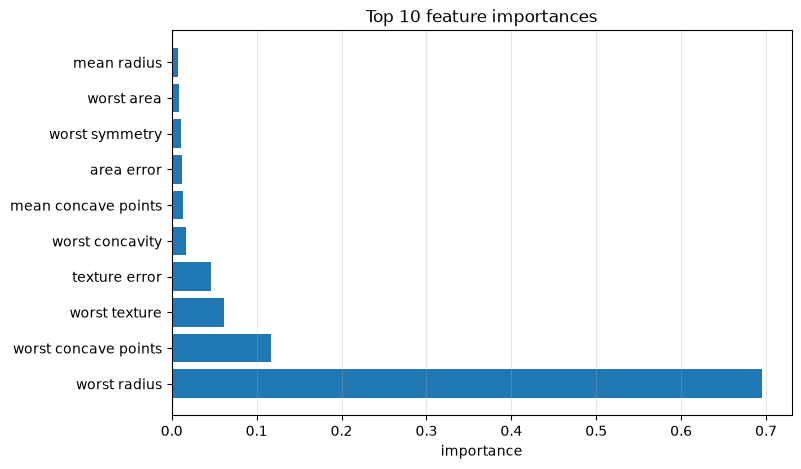

In [34]:
best_tree = DecisionTreeClassifier(random_state=42)
best_tree.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_tree.feature_importances_
}).sort_values('importance', ascending=False)

importance_df[:10]


display(importance_df[:10])

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'][:10], importance_df['importance'][:10])
plt.xlabel('importance')
plt.title('Top 10 feature importances')
plt.grid(axis='x', alpha=0.3)
plt.show()

## 문제 10. 기본 모델, 직접 비교, GridSearchCV 결과 비교

기본 결정트리와 사전 가지치기 결과, GridSearchCV 결과를 함께 비교하세요.

### 요구사항
- 기본 모델 평가셋 score
- 직접 비교에서 가장 좋은 평가셋 score
- GridSearchCV 선택 모델의 평가셋 score
- 세 값을 하나의 표로 정리

### 해석 포인트
- 교차검증으로 고른 후보가 항상 평가셋에서 최고가 되는 것은 아님.
- 평가셋은 최종 확인용이므로, 여러 설정을 평가셋에 반복적으로 맞추는 방식은 주의해야 함.

### 실행 결과
| method | train_score | test_score | tree_depth | leaf_count |
|---|---:|---:|---:|---:|
| base_tree | 1.000000 | 0.923077 | 7 | 18 |
| manual_best_test_score |  | 0.951049 |  |  |
| grid_search_best_tree | 0.988263 | 0.923077 | 7 | 14 |



In [35]:
manual_best_score = max(
    depth_result_df['test_score'].max(),
    split_result_df['test_score'].max(),
    leaf_result_df['test_score'].max()
)

comparison_df = pd.DataFrame([
    {
        'method': 'base_tree',
        'train_score': base_tree.score(X_train, y_train),
        'test_score': base_tree.score(X_test, y_test),
        'tree_depth': base_tree.get_depth(),
        'leaf_count': base_tree.get_n_leaves()
    },
    {
        'method': 'manual_best_test_score',
        'train_score': np.nan,
        'test_score': manual_best_score,
        'tree_depth': np.nan,
        'leaf_count': np.nan
    },
    {
        'method': 'grid_search_best_tree',
        'train_score': iris_best_model.score(X_train, y_train),
        'test_score': iris_best_model.score(X_test, y_test),
        'tree_depth': iris_best_model.get_depth(),
        'leaf_count': iris_best_model.get_n_leaves()
    }
])

display(comparison_df) 

,method,train_score,test_score,tree_depth,leaf_count
0,base_tree,1.000000,0.923077,7.0,18.0
1,manual_best_test_score,NaN,0.951000,NaN,NaN
2,grid_search_best_tree,0.988263,0.923077,7.0,14.0
